# Intro to Langgraph

LangGraph is an extension to LangChain

- LangChain: for simple chatbot solutions(answers customer's questions)
- LangGraph: more complicated problems (deep research Asistant)

With Langgraph we have State Graph and it enables us to add nodes.
Let's say we need this Assistant to make an internet research read blogs, forums, research papers and social media and then check if the info is trustworthy.

**Traditional Software:**
- 1- Fetch links from search engine
- 2- Loop through each link
- 3- Scrape Content + Feed LLM
- 4- Evaluate Credibility
- 5- Summarize Facts
- 6- Build Report


**LangGraph**
We create different nodes:

START NODE
    - gather news sources
    - scrape/clean content
    - evaluate trustworth
    - extract facts
END NODE

We Orchastrate them




## What is an AI agent?
- It is not an automation
- Can understand the content
- Make decisions
- They can adapt
- **Agent**= Goal+ Memory + Reasoning+ Action
- 1- give a goal
- 2- input method(how your agent is going to recieve the info)
- 3- brain

In [1]:
from IPython.display import Image
from typing import Dict, TypedDict
from langgraph.graph import StateGraph
#StateGraph: Used to define a graph-based workflow
#- Define nodes (steps)
#- Define edges (flow between steps)
#- Define shared state passed between steps

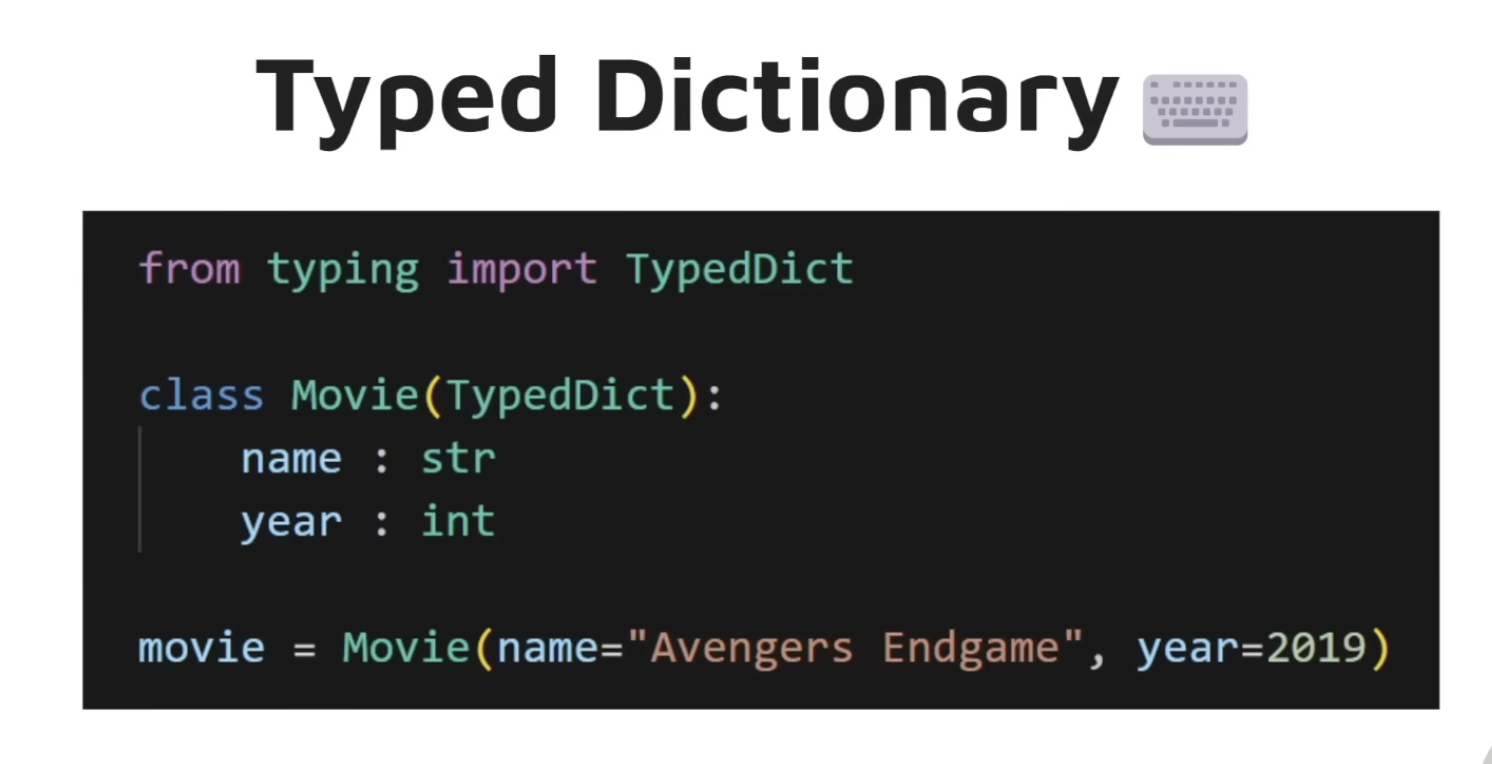

In [4]:
Image("images/typedict.png", width= 500)

## Agent State

In [5]:
class AgentState(TypedDict): #our state schema
    message: str


This defines the shape of the agent’s state. The state must be a dictionary with:
- key "message"
- value of type str

Think of it as a contract: every node must receive and return this structure.

```python
{
    "message": "some text"
}
```

In [6]:
def greeting_node(state: AgentState) -> AgentState:
    return {
        "message": f"Hey {state['message']}, how is your day going?"
    }

**state**: In LangGraph, this is the agent's current state (memory).

**state:AgentState** : The function expects state to follow the AgentState structure.

**AgentState**: This function must return a dictionary shaped like AgentState.

Our function receives an AgentState dictionary and returns an AgentState dictionary

This node takes a name like "Bob" and turns it into a greeting message, while respecting the state structure LangGraph requires.
This is basically:

- a function
- inside a graph that transforms state

NO intelligence yet.

In [7]:
graph = StateGraph(AgentState)
graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile() #Converts the graph into a runnable application

#even if the graph compiles without error,that does not mean it will work(there can be logical errors)
#entry point: Which node should run first?
#finish point

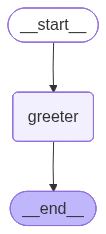

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
result =app.invoke({"message" : "Bob"})
print(result)

{'message': 'Hey Bob, how is your day going?'}


## We have a baby Agent
An agent is defined by:
- **State (memory / data)**  -> giving to the brain
- **Steps (nodes) that operate on that state** -> the brain
- **A control flow (what runs, and in what order)** -> the body

Our code has all three

But it’s a baby agent 👶 Because it:

- Has one node
- Has no branching
- Has no tools 
- Has no decisions
- Has no learning or memory across runs